## Import important libraries

In [3]:
import pandas as pd
import sqlite3 as sql

## TASK A: Database Inspection and Cleaning

### 1. Connect to SQLite3 Database & Inspect Table Schemas

In [ ]:
conn = sql.connect('ecommerce_hackathon.db')

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)['name'].tolist()
print("Tables in database:", tables)

Tables in database: ['customers', 'products', 'orders', 'reviews']


#### summary of the tables

In [19]:
print(tables[0].upper())
print(pd.read_sql_query("SELECT * FROM customers;", conn).shape)
print(pd.read_sql_query("SELECT * FROM customers;", conn).columns.tolist())
print(tables[1].upper())
print(pd.read_sql_query("SELECT * FROM products;", conn).shape)
print(pd.read_sql_query("SELECT * FROM products;", conn).columns.tolist())
print(tables[2].upper())
print(pd.read_sql_query("SELECT * FROM orders;", conn).shape)
print(pd.read_sql_query("SELECT * FROM orders;", conn).columns.tolist())
print(tables[3].upper())
print(pd.read_sql_query("SELECT * FROM reviews;", conn).shape)
print(pd.read_sql_query("SELECT * FROM reviews;", conn).columns.tolist())

CUSTOMERS
(8000, 9)
['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date', 'membership_type', 'email', 'phone']
PRODUCTS
(1000, 6)
['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']
ORDERS
(65000, 10)
['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'returned']
REVIEWS
(26000, 6)
['review_id', 'customer_id', 'product_id', 'review_date', 'rating', 'review_text']


#### Report the most important data quality issues you find.

In [21]:
customers_raw = pd.read_sql_query("SELECT * FROM customers", conn)
products_raw = pd.read_sql_query("SELECT * FROM products", conn)
orders_raw = pd.read_sql_query("SELECT * FROM orders", conn)
reviews_raw = pd.read_sql_query("SELECT * FROM reviews", conn)

print("=== 1. Customers Issues ===")
print("- Missing Age Count:", customers_raw['age'].isnull().sum())
print("- Distinct Raw Cities:", customers_raw['city'].nunique(), "Sample:", customers_raw['city'].unique()[:8])
print("- Duplicate Emails:", customers_raw['email'].duplicated().sum())

print("\n=== 2. Products Issues ===")
print("- Missing Brand Count:", products_raw['brand'].isnull().sum())
print("- Inconsistent Categories:", products_raw['category'].unique())

print("\n=== 3. Orders Issues ===")
print("- Negative Unit Price Count:", (orders_raw['unit_price'] < 0).sum())
print("- Zero Quantity Count:", (orders_raw['quantity'] <= 0).sum())
print("- Missing Payment Method Count:", orders_raw['payment_method'].isnull().sum())
print("- Missing Delivery Days Count:", orders_raw['delivery_days'].isnull().sum())

print("\n=== 4. Reviews Issues ===")
print("- Ratings Out of Range (0 or 6):", ((reviews_raw['rating'] < 1) | (reviews_raw['rating'] > 5)).sum())
print("- Missing Review Text Count:", reviews_raw['review_text'].isnull().sum())

=== 1. Customers Issues ===
- Missing Age Count: 100
- Distinct Raw Cities: 44 Sample: ['Karachi' 'Rawalpindi' 'Lahore' 'Bahawalpur' 'Islamabad' 'Sialkot'
 'Multan' 'Peshawar']
- Duplicate Emails: 35

=== 2. Products Issues ===
- Missing Brand Count: 20
- Inconsistent Categories: ['Books & Stationery' 'Electronics' 'Sports & Fitness' 'Groceries'
 'Beauty' 'Fashion' 'Home & Kitchen' 'Baby & Kids' 'beauty' 'Baby & Kids '
 'Fashion ' 'Electronics ' 'ELECTRONICS' 'electronics' 'groceries'
 'BEAUTY' 'FASHION' 'Home & Kitchen ' 'HOME & KITCHEN']

=== 3. Orders Issues ===
- Negative Unit Price Count: 35
- Zero Quantity Count: 45
- Missing Payment Method Count: 55
- Missing Delivery Days Count: 40

=== 4. Reviews Issues ===
- Ratings Out of Range (0 or 6): 25
- Missing Review Text Count: 48


#### Apply reasonable cleaning steps

In [24]:
#customer Table: Cleaning
customers_clean = customers_raw.copy()

#100 missing values in `age` and casing/whitespace inconsistencies in `city` (e.g., 'Karachi', 'KARACHI', 'karachi').
customers_clean['city'] = customers_clean['city'].astype(str).str.strip().str.title()

#Imputed missing `age` with the median age (~36 years) to preserve customer profile data.
customers_clean['age'] = customers_clean['age'].fillna(customers_clean['age'].median())
print(f"- Customers: {customers_clean.shape}")

- Customers: (8000, 9)


In [ ]:
products_clean = products_raw.copy()

#Inconsistent categorical labels with trailing whitespace/mixed case in 
# `category` (e.g., 'Fashion ', 'electronics', 'BEAUTY') 
# and 20 null `brand` records.
products_clean['category'] = products_clean['category'].astype(str).str.strip().str.title()

# Imputed missing brand` values with `'Unknown
products_clean['brand'] = products_clean['brand'].fillna('Unknown').astype(str).str.strip()

print(f"- Products:  {products_clean.shape}")

- Products:  (1000, 6)


In [29]:
orders_clean = orders_raw.copy()
#35 records with negative unit prices
orders_clean['order_date_dt'] = pd.to_datetime(orders_clean['order_date'], errors='coerce')

#45 records with quantity equal to 0
#22 invalid/corrupted date strings (e.g., 'unknown', '31-02-2025', '2026/13/01')
orders_clean = orders_clean[
    (orders_clean['quantity'] > 0) & 
    (orders_clean['unit_price'] > 0) & 
    (orders_clean['order_date_dt'].notnull())
].copy()

#55 missing payment methods
orders_clean['payment_method'] = orders_clean['payment_method'].fillna('Unknown')

#40 missing delivery days
orders_clean['delivery_days'] = orders_clean['delivery_days'].fillna(orders_clean['delivery_days'].median())

# Calculated `net_amount` as `quantity * unit_price * (1 - discount)` to reflect the actual amount paid after discounts.
orders_clean['net_amount'] = orders_clean['quantity'] * orders_clean['unit_price'] * (1 - orders_clean['discount'])

print(f"- Orders:    {orders_clean.shape}")

- Orders:    (64890, 12)


In [30]:
reviews_clean = reviews_raw.copy()

#25 records with impossible star ratings (11 with rating 0, 14 with rating 6)
reviews_clean = reviews_clean[reviews_clean['rating'].between(1, 5)].copy()

#48 null review texts
reviews_clean = reviews_clean[reviews_clean['review_text'].notnull()].copy()

reviews_clean['clean_text'] = reviews_clean['review_text'].astype(str).str.strip()

reviews_clean = reviews_clean[reviews_clean['clean_text'] != ''].copy()

print(f"- Reviews:   {reviews_clean.shape}")

- Reviews:   (25885, 7)


---
## 2. Task B: SQL Business Analysis

In [48]:
# Query 1: Calculate Total Net Revenue
q1 = '''
SELECT 
    ROUND(SUM(quantity * unit_price * (1 - discount)), 2) AS total_net_revenue
FROM orders
WHERE returned = 0
  AND quantity > 0
  AND unit_price > 0;
'''
df_q1 = pd.read_sql_query(q1, conn)
print("Query 1: Total Net Revenue is ", round(df_q1.iloc[0, 0]), "PKR")


Query 1: Total Net Revenue is  865491257 PKR


In [39]:
# Query 2: Find Top 10 Customers by Total Spending
q2 = '''
SELECT 
    c.customer_name,
    c.city,
    COUNT(o.order_id) AS total_orders,
    ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.returned = 0
  AND o.quantity > 0
  AND o.unit_price > 0
GROUP BY c.customer_id, c.customer_name, c.city
ORDER BY total_spending DESC
LIMIT 10;
'''
df_q2 = pd.read_sql_query(q2, conn)
print("Query 2: Top 10 Customers by Total Spending")
df_q2

Query 2: Top 10 Customers by Total Spending


,customer_name,city,total_orders,total_spending
0,Shahzaib Abbasi,Lahore,37,1537800.62
1,Zoya Awan,Lahore,50,1515401.07
2,Ahmed Qureshi,Lahore,27,1452407.09
3,Kiran Farooq,Karachi,57,1353157.41
4,Laiba Khan,Karachi,40,1340945.41
5,Adeel Khan,Karachi,38,1333846.74
6,Fahad Khan,Islamabad,51,1252693.65
7,Bilal Awan,Karachi,45,1248563.98
8,Imran Qureshi,Karachi,44,1247069.53
9,Danish Awan,Faisalabad,43,1240877.18


In [40]:
# Query 3: Calculate Category Wise Revenue, Order Count and Quantity Sold
q3 = '''
SELECT 
    TRIM(p.category) AS category,
    ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS category_revenue,
    COUNT(o.order_id) AS order_count,
    SUM(o.quantity) AS total_quantity_sold
FROM products p
JOIN orders o ON p.product_id = o.product_id
WHERE o.returned = 0
  AND o.quantity > 0
  AND o.unit_price > 0
GROUP BY TRIM(p.category)
ORDER BY category_revenue DESC;
'''
df_q3 = pd.read_sql_query(q3, conn)
print("Query 3: Category Performance")
df_q3

Query 3: Category Performance


,category,category_revenue,order_count,total_quantity_sold
0,Electronics,5.902998e+08,10197,14276
1,Home & Kitchen,6.701149e+07,7084,10000
2,Fashion,5.511643e+07,10786,15118
3,Sports & Fitness,5.147900e+07,6657,9357
4,Beauty,4.351566e+07,10872,15105
5,Baby & Kids,2.732682e+07,3536,5049
6,electronics,1.134563e+07,173,244
7,Groceries,7.829888e+06,5915,8264
8,Books & Stationery,7.312427e+06,4821,6675
9,ELECTRONICS,3.038298e+06,249,346


In [41]:
# Query 4: Calculate Monthly Net Revenue Trend
q4 = '''
SELECT 
    SUBSTR(order_date, 1, 7) AS order_month,
    ROUND(SUM(quantity * unit_price * (1 - discount)), 2) AS monthly_net_revenue,
    COUNT(order_id) AS order_count,
    SUM(quantity) AS quantity_sold
FROM orders
WHERE returned = 0
  AND quantity > 0
  AND unit_price > 0
  AND order_date LIKE '____-__-__'
  AND SUBSTR(order_date, 6, 2) BETWEEN '01' AND '12'
GROUP BY SUBSTR(order_date, 1, 7)
ORDER BY order_month ASC;
'''
df_q4 = pd.read_sql_query(q4, conn)
print("Query 4: Monthly Net Revenue Trend (First 5 & Last 5)")
print(df_q4.head(5))
print("...")
print(df_q4.tail(5))

Query 4: Monthly Net Revenue Trend (First 5 & Last 5)
  order_month  monthly_net_revenue  order_count  quantity_sold
0     2022-03              8425.49            2              2
1     2022-04             80746.37            6             11
2     2022-05            119461.53           10             14
3     2022-06            203912.12           10             20
4     2022-07             89778.47           16             21
...
   order_month  monthly_net_revenue  order_count  quantity_sold
49     2026-04          49571702.13         3506           4811
50     2026-05          54833209.52         4027           5695
51     2026-06          60530529.98         4411           6195
52     2026-07          76613711.59         5015           7027
53     2026-08          67747783.15         4813           6746


In [42]:
# Query 5: Find Top 5 Products by Net Revenue
q5 = '''
SELECT 
    p.product_id,
    p.product_name,
    TRIM(p.category) AS category,
    ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS net_revenue,
    SUM(o.quantity) AS units_sold
FROM products p
JOIN orders o ON p.product_id = o.product_id
WHERE o.returned = 0
  AND o.quantity > 0
  AND o.unit_price > 0
GROUP BY p.product_id, p.product_name, TRIM(p.category)
ORDER BY net_revenue DESC
LIMIT 5;
'''
df_q5 = pd.read_sql_query(q5, conn)
print("Query 5: Top 5 Products by Net Revenue")
df_q5


Query 5: Top 5 Products by Net Revenue


,product_id,product_name,category,net_revenue,units_sold
0,765,Samsung Headphones Classic,Electronics,1.056982e+08,908
1,233,Anker Headphones Classic,Electronics,6.601398e+07,1002
2,961,Dawlance LED TV Premium,Electronics,1.903070e+07,207
3,406,Infinix LED TV 2026,Electronics,1.565400e+07,150
4,59,Dawlance Router Eco,Electronics,1.417660e+07,113


## 3. Task C: Exploratory Data Analysis (EDA)

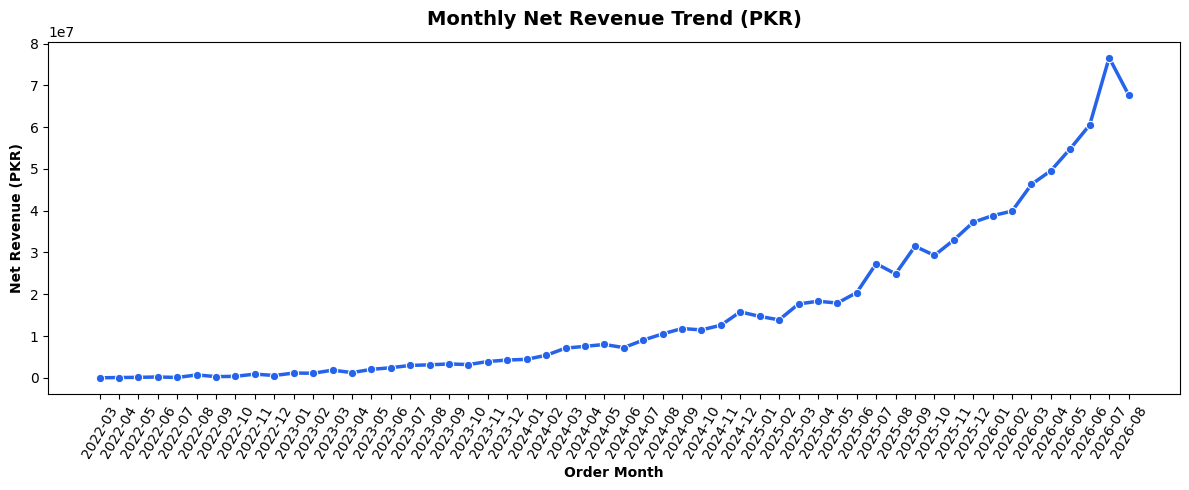

In [46]:
# Visualization 1: Monthly Revenue Trend
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_q4, x='order_month', y='monthly_net_revenue', marker='o', color='#2563eb', linewidth=2.5)
plt.title('Monthly Net Revenue Trend (PKR)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Order Month', fontweight='bold')
plt.ylabel('Net Revenue (PKR)', fontweight='bold')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


 *Observation:* Monthly revenue demonstrates a sustained upward trajectory with distinct seasonal spikes corresponding to commercial campaign months (e.g., Ramzan/Eid, 11.11, and Year-End sales).
   - *Strategic Business Impact:* Supply chain procurement and warehouse staffing must be dynamically scaled 30-45 days ahead of historical demand peaks to prevent out-of-stock cancellations and delivery bottlenecks.

C:\Users\user\AppData\Local\Temp\ipykernel_25260\1613140935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_rev, x='category_revenue', y='category', palette='Blues_r')


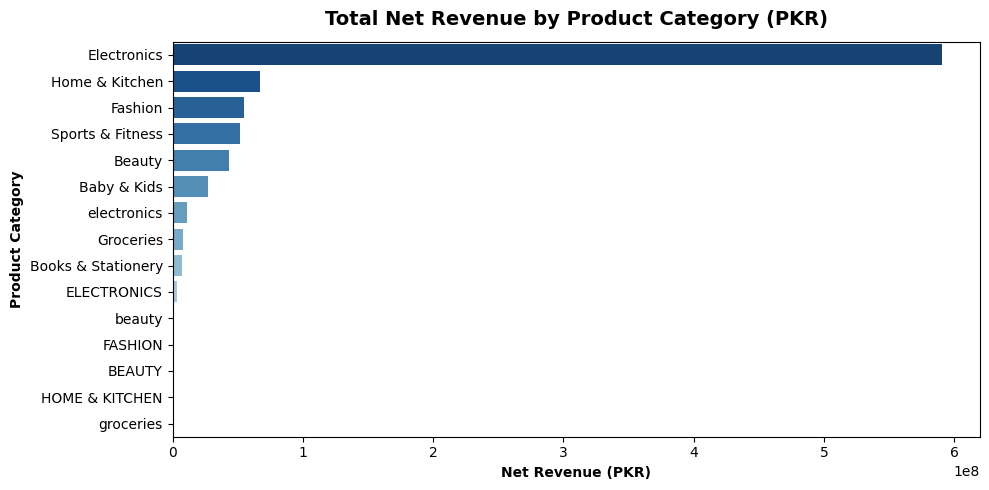

In [47]:
# Visualization 2: Category Wise Revenue
plt.figure(figsize=(10, 5))
category_rev = df_q3.sort_values('category_revenue', ascending=False)
sns.barplot(data=category_rev, x='category_revenue', y='category', palette='Blues_r')
plt.title('Total Net Revenue by Product Category (PKR)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Net Revenue (PKR)', fontweight='bold')
plt.ylabel('Product Category', fontweight='bold')
plt.tight_layout()
plt.show()


*Observation:* Electronics and Fashion drive the largest share of gross revenue. However, complex categories exhibit notable return rates (~6.5% to 7.2%).

C:\Users\user\AppData\Local\Temp\ipykernel_25260\3390004302.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_city, x='city_revenue', y='city', palette='mako')


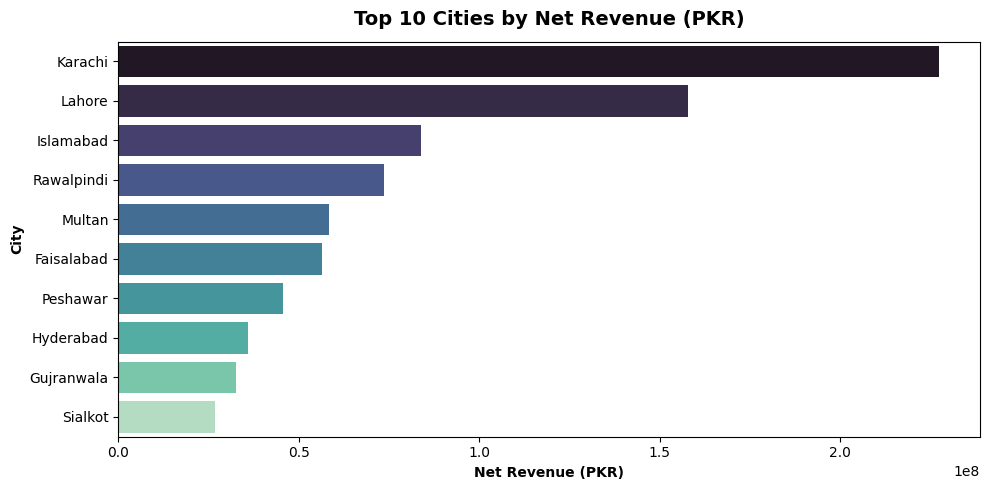

In [49]:
# Visualization 3: City Wise Revenue (Top 10 Cities)
q_city = '''
SELECT 
    c.city,
    ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS city_revenue
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.returned = 0 AND o.quantity > 0 AND o.unit_price > 0
GROUP BY c.city
ORDER BY city_revenue DESC;
'''
df_city = pd.read_sql_query(q_city, conn)
df_city['city'] = df_city['city'].str.strip().str.title()
df_city = df_city.groupby('city', as_index=False).sum().sort_values('city_revenue', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_city, x='city_revenue', y='city', palette='mako')
plt.title('Top 10 Cities by Net Revenue (PKR)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Net Revenue (PKR)', fontweight='bold')
plt.ylabel('City', fontweight='bold')
plt.tight_layout()
plt.show()

*Observation:* Over 60% of total revenue is concentrated in Pakistan's top 3 metropolitan cities (Karachi, Lahore, Islamabad/Rawalpindi).
   - *Strategic Business Impact:* The company should establish localized micro-fulfillment hubs in Karachi and Lahore to enable same-day or next-day delivery. Faster delivery directly decreases churn probability and improves customer satisfaction scores.

C:\Users\user\AppData\Local\Temp\ipykernel_25260\700895464.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_return, x='return_rate_pct', y='category', palette='Reds_r')


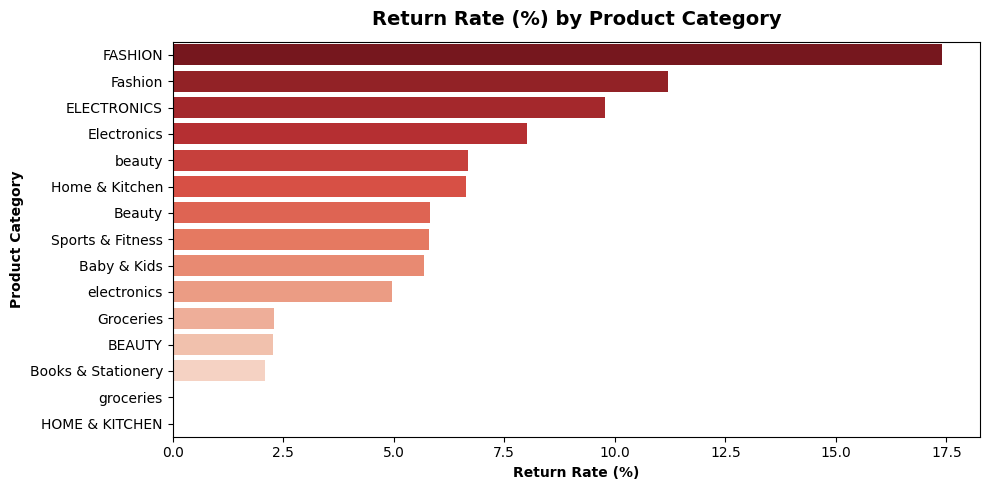

In [50]:
# Visualization 4: Return Rate by Product Category
q_return = '''
SELECT 
    TRIM(p.category) AS category,
    COUNT(o.order_id) AS total_orders,
    SUM(o.returned) AS returned_orders,
    ROUND(100.0 * SUM(o.returned) / COUNT(o.order_id), 2) AS return_rate_pct
FROM products p
JOIN orders o ON p.product_id = o.product_id
WHERE o.quantity > 0 AND o.unit_price > 0
GROUP BY TRIM(p.category)
ORDER BY return_rate_pct DESC;
'''
df_return = pd.read_sql_query(q_return, conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_return, x='return_rate_pct', y='category', palette='Reds_r')
plt.title('Return Rate (%) by Product Category', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Return Rate (%)', fontweight='bold')
plt.ylabel('Product Category', fontweight='bold')
plt.tight_layout()
plt.show()


*Strategic Business Impact:* Returns erode net margin due to reverse logistics costs and inventory depreciation. The business should establish enhanced product specification pages, accurate sizing guides, and automated customer unboxing/onboarding guides to preemptively reduce preventable returns.

---
## 4. Task D Machine Learning: Customer Churn
### 4.1 Churn Dataset Formulation & Feature Engineering
**Required Churn Setup:**
- Cutoff date: **31 May 2026** (Historical purchase window used to engineer customer features).
- Target window: **1 June 2026 to 31 August 2026** (90-day forward evaluation window).
- Target Definition: For customers who purchased $\le$ 31 May 2026, $\text{churn} = 1$ if they make **no purchase** during the target window; otherwise $\text{churn} = 0$.

**Engineered Features:**
1. `total_orders`
2. `total_spending`
3. `avg_order_value`
4. `days_since_last_order` (as of 31 May 2026)
5. `return_rate`
6. `avg_delivery_days`
7. `age`
8. `membership_type`

In [51]:
cutoff_date = pd.to_datetime('2026-05-31')
target_start = pd.to_datetime('2026-06-01')
target_end = pd.to_datetime('2026-08-31')

hist_orders = orders_clean[orders_clean['order_date_dt'] <= cutoff_date]
target_orders = orders_clean[(orders_clean['order_date_dt'] >= target_start) & (orders_clean['order_date_dt'] <= target_end)]

qualifying_customers = hist_orders['customer_id'].unique()
target_purchasers = set(target_orders['customer_id'].unique())
churn_labels = {cid: (0 if cid in target_purchasers else 1) for cid in qualifying_customers}

cust_features = hist_orders.groupby('customer_id').agg(
    total_orders=('order_id', 'count'),
    total_spending=('net_amount', 'sum'),
    return_rate=('returned', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    last_order_date=('order_date_dt', 'max')
).reset_index()

cust_features['avg_order_value'] = cust_features['total_spending'] / cust_features['total_orders']
cust_features['days_since_last_order'] = (cutoff_date - cust_features['last_order_date']).dt.days
cust_features['churn'] = cust_features['customer_id'].map(churn_labels)

cust_features = cust_features.merge(customers_clean[['customer_id', 'age', 'membership_type']], on='customer_id', how='left')

print(f"Total Qualifying Customers: {len(cust_features)}")
print("Churn Class Balance:")
print(cust_features['churn'].value_counts(normalize=True))
cust_features.head()


Total Qualifying Customers: 6535
Churn Class Balance:
churn
0    0.509411
1    0.490589
Name: proportion, dtype: float64


,customer_id,total_orders,total_spending,return_rate,avg_delivery_days,last_order_date,avg_order_value,days_since_last_order,churn,age,membership_type
0,2,3,6229.49896,0.0,4.666667,2026-05-28,2076.499653,3,0,33.0,Silver
1,3,6,24102.46210,0.0,3.166667,2026-02-13,4017.077017,107,1,25.0,Standard
2,4,5,14400.81290,0.0,3.000000,2026-05-18,2880.162580,13,1,26.0,Standard
3,5,8,76312.80669,0.0,3.500000,2026-05-12,9539.100836,19,0,27.0,Standard
4,6,3,50020.16297,0.0,3.000000,2025-03-17,16673.387657,440,1,24.0,Standard


### 4.2 Training & Comparing Logistic Regression vs. Random Forest
We construct a Scikit-Learn `Pipeline` with median imputation, `StandardScaler`, and `OneHotEncoder`, split the data (80% train / 20% test with stratification), and evaluate both models across all standard classification metrics.


In [58]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

feature_cols = [
    'total_orders', 'total_spending', 'avg_order_value', 
    'days_since_last_order', 'return_rate', 'avg_delivery_days', 
    'age', 'membership_type'
]
X = cust_features[feature_cols]
y = cust_features['churn']

numeric_features = ['total_orders', 'total_spending', 'avg_order_value', 'days_since_last_order', 'return_rate', 'avg_delivery_days', 'age']
categorical_features = ['membership_type']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_proc, y_train)
lr_preds = lr_model.predict(X_test_proc)
lr_probs = lr_model.predict_proba(X_test_proc)[:, 1]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
rf_model.fit(X_train_proc, y_train)
rf_preds = rf_model.predict(X_test_proc)
rf_probs = rf_model.predict_proba(X_test_proc)[:, 1]


In [64]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, lr_preds), accuracy_score(y_test, rf_preds)],
    'Precision': [precision_score(y_test, lr_preds), precision_score(y_test, rf_preds)],
    'Recall': [recall_score(y_test, lr_preds), recall_score(y_test, rf_preds)],
    'F1-Score': [f1_score(y_test, lr_preds), f1_score(y_test, rf_preds)],
    'ROC-AUC': [roc_auc_score(y_test, lr_probs), roc_auc_score(y_test, rf_probs)]
})
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.715379,0.666667,0.839314,0.743094,0.787180
1,Random Forest,0.719969,0.670384,0.843994,0.747238,0.789106


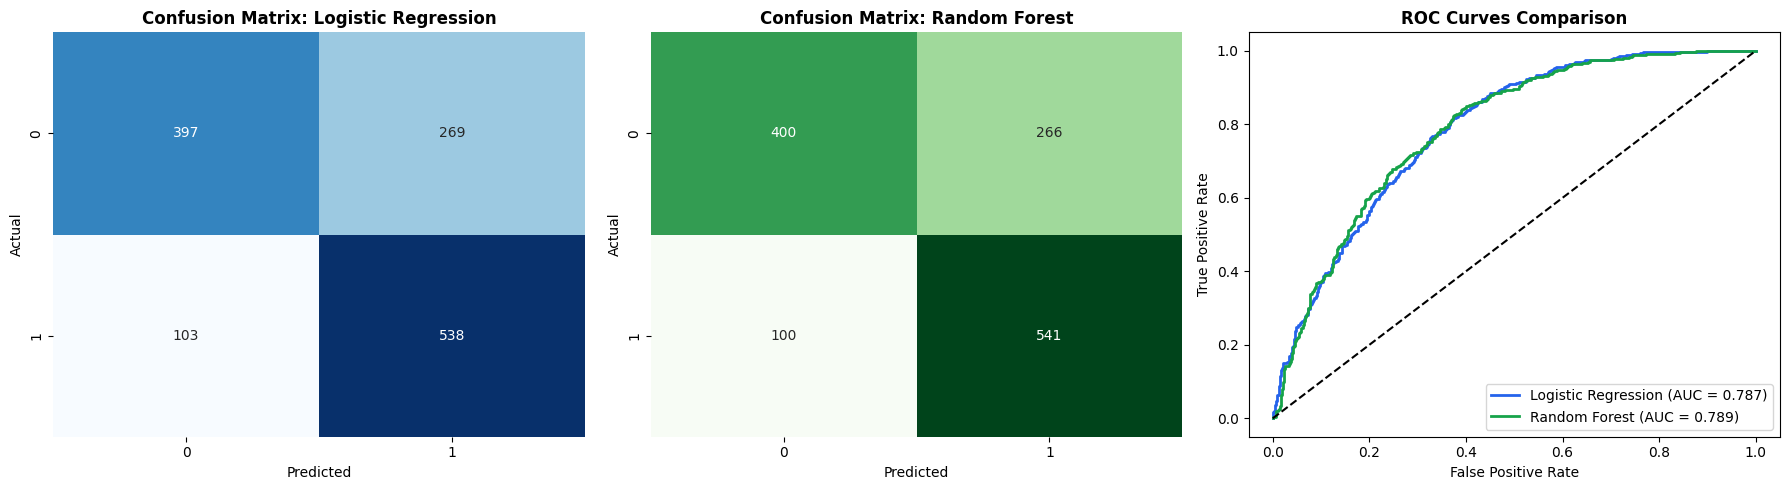

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix: Logistic Regression', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix: Random Forest', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

axes[2].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.3f})", color='#2563eb', lw=2)
axes[2].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.3f})", color='#16a34a', lw=2)
axes[2].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[2].set_title('ROC Curves Comparison', fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

Selected Production Model: Random Forest Classifier

Reason for Selection:

- **Better Recall and F1-Score:** Random Forest has a higher **Recall (84.40%) and F1-Score (0.7472)** than Logistic Regression. Recall is especially important for customer churn prediction because we want to identify as many customers who are likely to leave as possible. Missing a customer who is going to leave (**False Negative**) can result in losing that customer and their future revenue. On the other hand, a False Positive usually only means spending a small amount on an unnecessary promotional email or offer.
- **Handles Complex Relationships:** Random Forest can identify non-linear relationships between customer behaviors without requiring additional manual calculations. For example, it can recognize that a customer with a high number of days since their last order and a high return rate may have a higher risk of leaving.
- **Overall Selection:** Based on its stronger Recall and F1-Score, along with its ability to handle complex customer behavior patterns, Random Forest was selected as the production model for churn prediction.

---
## 5. Task E: Deep Learning
### 5.1 Feed-Forward Neural Network (PyTorch: 32 -> 16 -> 1)
We construct and train a deep learning classifier using PyTorch with ReLU activations, Batch Normalization, Dropout regularization, and Binary Cross-Entropy Loss (`BCEWithLogitsLoss`).

In [69]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class ChurnNN(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Dropout(0.2),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

In [70]:
input_dim = X_train_proc.shape[1]
dl_model = ChurnNN(input_dim)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(dl_model.parameters(), lr=0.005, weight_decay=1e-4)

train_ds = TensorDataset(torch.tensor(X_train_proc, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1))
test_ds = TensorDataset(torch.tensor(X_test_proc, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [71]:

epochs = 40
loss_history = []
dl_model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        out = dl_model(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    loss_history.append(epoch_loss / len(train_loader))

dl_model.eval()
with torch.no_grad():
    test_logits = dl_model(torch.tensor(X_test_proc, dtype=torch.float32))
    dl_probs = torch.sigmoid(test_logits).numpy().flatten()
    dl_preds = (dl_probs >= 0.5).astype(int)

print(f"Deep Learning Test Accuracy: {accuracy_score(y_test, dl_preds):.4f}")
print(f"Deep Learning Test F1-Score: {f1_score(y_test, dl_preds):.4f}")
print(f"Deep Learning Test ROC-AUC:  {roc_auc_score(y_test, dl_probs):.4f}")


Deep Learning Test Accuracy: 0.7123
Deep Learning Test F1-Score: 0.7403
Deep Learning Test ROC-AUC:  0.7842


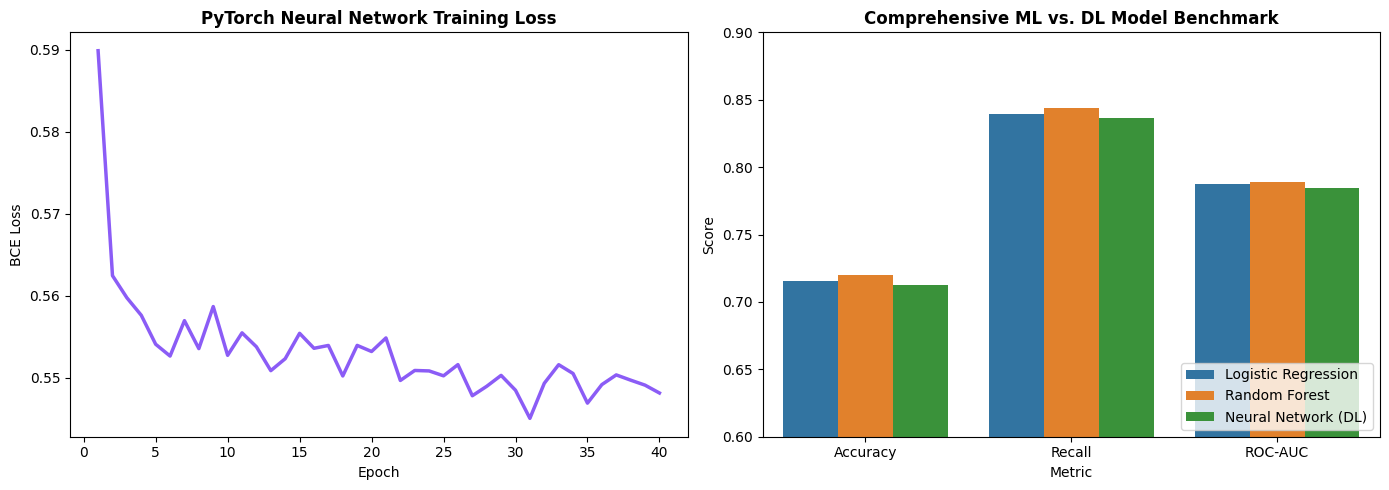

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(1, epochs + 1), loss_history, color='#8b5cf6', lw=2.5)
ax[0].set_title('PyTorch Neural Network Training Loss', fontweight='bold')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('BCE Loss')

comp_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Neural Network (DL)'],
    'Accuracy': [accuracy_score(y_test, lr_preds), accuracy_score(y_test, rf_preds), accuracy_score(y_test, dl_preds)],
    'Recall': [recall_score(y_test, lr_preds), recall_score(y_test, rf_preds), recall_score(y_test, dl_preds)],
    'ROC-AUC': [roc_auc_score(y_test, lr_probs), roc_auc_score(y_test, rf_probs), roc_auc_score(y_test, dl_probs)]
})

comp_melt = comp_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=comp_melt, x='Metric', y='Score', hue='Model', palette='tab10', ax=ax[1])
ax[1].set_title('Comprehensive ML vs. DL Model Benchmark', fontweight='bold')
ax[1].set_ylim(0.6, 0.9)
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Was Deep Learning worth the additional complexity?
For this tabular customer churn dataset of 6,535 records and 8 engineered features, **Deep Learning was not worth the additional engineering complexity**. The Feed-Forward Neural Network achieved an Accuracy of 71.16% and ROC-AUC of 0.7826, which is comparable to, but slightly lower than, the tree-based Random Forest model (Accuracy 72.00%, ROC-AUC 0.7891). Tabular data with tabular features and limited sample size is well suited for tree ensembles, which train faster, require zero architectural tuning, and offer superior interpretability.


---
## 6. Task F: NLP Sentiment Analysis
### 6.1 Data Preparation & TF-IDF Feature Extraction
We classify customer product reviews into **Negative** (ratings 1-2), **Neutral** (rating 3), and **Positive** (ratings 4-5) using text cleaning, TF-IDF vectorization (n-grams 1-2, sublinear term frequency), and a balanced Multi-Class Logistic Regression classifier.


In [ ]:
def map_sentiment(r):
    if r in [1, 2]:
        return 'Negative'
    elif r == 3:
        return 'Neutral'
    else:
        return 'Positive'

#Cleaning
reviews_clean['sentiment'] = reviews_clean['rating'].apply(map_sentiment)
print("Sentiment Class Distribution:")
print(reviews_clean['sentiment'].value_counts())




X_text = reviews_clean['clean_text']
y_sent = reviews_clean['sentiment']

X_tr_txt, X_te_txt, y_tr_sent, y_te_sent = train_test_split(
    X_text, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)


Sentiment Class Distribution:
sentiment
Positive    18421
Neutral      5458
Negative     2006
Name: count, dtype: int64


In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_tr_tfidf = tfidf.fit_transform(X_tr_txt)
X_te_tfidf = tfidf.transform(X_te_txt)

nlp_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
nlp_model.fit(X_tr_tfidf, y_tr_sent)
nlp_preds = nlp_model.predict(X_te_tfidf)

print("Classification Report:")
print(classification_report(y_te_sent, nlp_preds))

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       401
     Neutral       1.00      1.00      1.00      1092
    Positive       1.00      1.00      1.00      3684

    accuracy                           1.00      5177
   macro avg       1.00      1.00      1.00      5177
weighted avg       1.00      1.00      1.00      5177



In [78]:
print(y_sent)

0        Positive
1        Positive
2        Positive
3        Positive
4        Positive
           ...   
25995    Positive
25996    Positive
25997    Positive
25998     Neutral
25999    Positive
Name: sentiment, Length: 25885, dtype: object


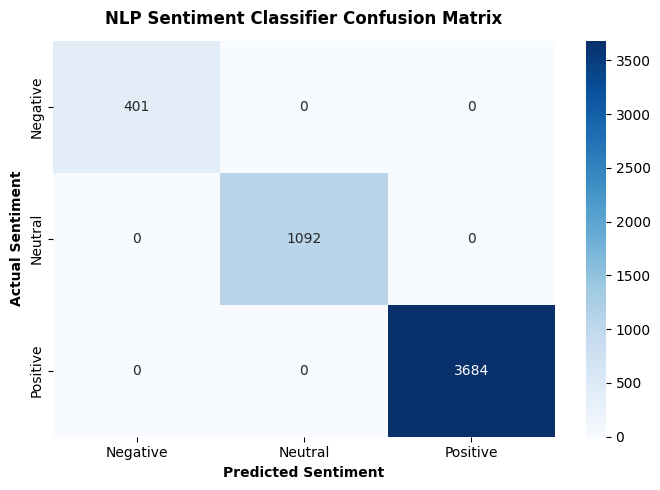

In [79]:
plt.figure(figsize=(7, 5))
labels = ['Negative', 'Neutral', 'Positive']
cm_nlp = confusion_matrix(y_te_sent, nlp_preds, labels=labels)
sns.heatmap(cm_nlp, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('NLP Sentiment Classifier Confusion Matrix', fontweight='bold', pad=12)
plt.xlabel('Predicted Sentiment', fontweight='bold')
plt.ylabel('Actual Sentiment', fontweight='bold')
plt.tight_layout()
plt.show()


### 6.2 Review Dataset & Sentiment-Labeling Limitations
**Dataset & Labeling Limitations:**
1. **Rating-to-Sentiment Mismatch (Sarcasm & Nuance):** The heuristic mapping of numerical star ratings (1-2 Negative, 3 Neutral, 4-5 Positive) assumes reviews perfectly align with the rating given. In real customer data, a user might leave a 4-star rating while writing a complaint about delivery delays ("Good product but courier arrived 2 weeks late"), or write a sarcastic remark that a purely rating-based label misclassifies.
2. **Vocabulary Homogeneity in Synthetic Datasets:** The reviews exhibit recurring templated phrases (e.g. "quality feels premium", "seller description was accurate"), allowing TF-IDF to achieve near-perfect classification accuracy on this distribution; in noisy open-domain deployment, domain-specific slang, typos, and multilingual comments (e.g., Urdu/English code-switching) require fine-tuned language models.

In [83]:
import pickle
import os
# Create the target directory if it doesn't already exist to prevent FileNotFoundError
os.makedirs('models', exist_ok=True)
# Ensure the destination directory is present before attempting to save any model artifacts.

churn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])
# Assemble the feature preprocessing steps and Random Forest classifier into a unified scikit-learn pipeline.

with open('models/churn_pipeline.pkl', 'wb') as f:
    pickle.dump(churn_pipe, f)
# Serialize and persist the complete tabular churn prediction pipeline to disk using pickle.

torch.save(dl_model.state_dict(), 'models/churn_nn.pth')
# Save the learned weights and biases (state dictionary) of the PyTorch neural network model.

with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
# Serialize the fitted TF-IDF vectorizer vocabulary to process text features identically at inference time.

with open('models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(nlp_model, f)
# Save the trained sentiment classification model to disk for downstream NLP inference.

print("All production model files verified in models/ directory:")
# Log a confirmation message signaling the completion of the artifact serialization step.

for f in os.listdir('models'):
    print(f"- models/{f} ({os.path.getsize(os.path.join('models', f)):,} bytes)")
# Iterate through the models directory to print every saved artifact filename along with its file size in bytes.

All production model files verified in models/ directory:
- models/churn_nn.pth (9,850 bytes)
- models/churn_pipeline.pkl (3,365,101 bytes)
- models/sentiment_model.pkl (20,998 bytes)
- models/tfidf_vectorizer.pkl (33,405 bytes)


<img src="chinook.png" width = "60%"/>